# A more detailed introduction

The following notebook expands a bit on the "Getting started" one.

In [1]:
import jax
import os
import sbijax
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator, AutoLocator

## Model definition

To do approximate inference using `sbijax`, a user first has to define a prior model and a simulator function which can be used to generate synthetic data. We will be using a simple bivariate Gaussian as an example with the following generative model:

\begin{align}
\mu &\sim \mathcal{N}_2(0, I)\\
\sigma &\sim \mathcal{N}^+(1)\\
y & \sim \mathcal{N}_2(\mu, \sigma^2 I)
\end{align}

Using TensorFlow Probability, the prior model and simulator are implemented like this:

In [2]:
from jax import numpy as jnp, random as jr
from tensorflow_probability.substrates.jax import distributions as tfd

def prior_fn():
    prior = tfd.JointDistributionNamed(dict(
        mean=tfd.Normal(jnp.zeros(2), 1.0),
        scale=tfd.HalfNormal(jnp.ones(1)),
    ), batch_ndims=0)
    return prior

def simulator_fn(seed: jr.PRNGKey, theta: dict[str, jax.Array]):
    p = tfd.Normal(jnp.zeros_like(theta["mean"]), 1.0)
    y = theta["mean"] + theta["scale"] * p.sample(seed=seed)
    return y

In [3]:
prior = prior_fn()
theta = prior.sample(seed=jr.PRNGKey(0), sample_shape=())
theta

{'scale': Array([0.47995827], dtype=float32),
 'mean': Array([0.62157685, 0.8429717 ], dtype=float32)}

In [4]:
prior.log_prob(theta)

Array(-2.7273278, dtype=float32)

In [5]:
simulator_fn(seed=jr.PRNGKey(1), theta=theta)

Array([0.54745346, 0.88362765], dtype=float32)

In [6]:
theta = prior.sample(seed=jr.PRNGKey(2), sample_shape=(2,))
theta

{'scale': Array([[0.48404777],
        [0.3731677 ]], dtype=float32),
 'mean': Array([[ 1.2550716 ,  0.27969918],
        [-0.66132253, -0.79632473]], dtype=float32)}

In [7]:
prior.log_prob(theta)

Array([-3.0075376, -2.6690357], dtype=float32)

In [8]:
simulator_fn(seed=jr.PRNGKey(3), theta=theta)

Array([[ 0.5550142 ,  1.0248331 ],
       [-0.51858354, -0.0609225 ]], dtype=float32)

## Algorithm definition

Having defined a model of interest, i.e., the prior and simulator functions, we construct an inferential method. We can use a pre-implemented method to construct a normalizing flow, but for the sake of demonstration we implement a MAF from scratch.

In [9]:
import haiku as hk
import surjectors
import surjectors.nn
import surjectors.util
from sbijax import NLE

In [10]:
n_dim_data = 2
n_layers, hidden_sizes = 5, (64, 64)

In [11]:
def make_custom_affine_maf(n_dimension, n_layers, hidden_sizes):
    def _bijector_fn(params):
        means, log_scales = surjectors.util.unstack(params, -1)
        return surjectors.ScalarAffine(means, jnp.exp(log_scales))

    def _flow(method, **kwargs):
        layers = []
        order = jnp.arange(n_dimension)
        for _ in range(5):
            layer = surjectors.MaskedAutoregressive(
                bijector_fn=_bijector_fn,
                conditioner=surjectors.nn.MADE(
                    n_dimension,
                    list(hidden_sizes),
                    2,
                    w_init=hk.initializers.TruncatedNormal(0.001),
                    b_init=jnp.zeros,
                ),
            )
            order = order[::-1]
            layers.append(layer)
            layers.append(surjectors.Permutation(order, 1))
        chain = surjectors.Chain(layers[:-1])
        base_distribution = tfd.Independent(
            tfd.Normal(jnp.zeros(n_dimension), jnp.ones(n_dimension)),
            1,
        )
        td = surjectors.TransformedDistribution(base_distribution, chain)
        return td(method, **kwargs)

    td = hk.transform(_flow)
    return td

In [12]:
fns = prior_fn, simulator_fn
neural_network = make_custom_affine_maf(n_dim_data, n_layers, hidden_sizes)
model = NLE(fns, neural_network)

## Training and Inference

Inference is then as easy as simulating some data, fitting the data to the model, a sampling from the approximate posterior. The data set is a dictionary of dictionaries (a PyTree in JAX lingo). It contains samples for the simulator function, called `y`, and parameter samples from the prior model, called `theta`.

In [13]:
data, _ = model.simulate_data(
    jr.PRNGKey(1),
    n_simulations=10_000,
)
data

{'y': Array([[ 0.07692909,  0.7882271 ],
        [-1.2418504 , -0.25333643],
        [ 1.1943562 , -2.124853  ],
        ...,
        [ 1.3316323 ,  0.5488601 ],
        [ 4.862982  , -4.1227694 ],
        [-0.00955033,  0.989019  ]], dtype=float32),
 'theta': {'scale': Array([[0.9232396 ],
         [0.36471593],
         [0.6795394 ],
         ...,
         [0.11454558],
         [1.260745  ],
         [0.5012804 ]], dtype=float32),
  'mean': Array([[ 0.30212572,  0.67478853],
         [-0.963459  ,  0.086253  ],
         [ 0.39044896, -2.2378268 ],
         ...,
         [ 1.3652769 ,  0.6302657 ],
         [ 2.7543025 , -1.9100804 ],
         [-0.16545922,  0.6475435 ]], dtype=float32)}}

We then fit the model using the typical flow matching loss.

In [14]:
params, losses = model.fit(
    jr.PRNGKey(2),
    data=data,
)

 27%|████████████████████████████████████████████████████████████████████████████████▉                                                                                                                                                                                                                              | 267/1000 [02:54<08:00,  1.53it/s]


Finally, we sample from the posterior distribution for a specific observation $y_{\text{obs}}$.

In [15]:
y_obs = jnp.array([-1.0, 1.0])
inference_results, diagnostics = model.sample_posterior(
    jr.PRNGKey(3), params, y_obs, n_chains=4, n_samples=10_000, n_warmup=5_000
)

In [16]:
print(inference_results)

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:    (chain: 4, draw: 5000, mean_dim: 2, scale_dim: 1)
│       Coordinates:
│         * chain      (chain) int64 32B 0 1 2 3
│         * draw       (draw) int64 40kB 0 1 2 3 4 5 6 ... 4994 4995 4996 4997 4998 4999
│         * mean_dim   (mean_dim) int64 16B 0 1
│         * scale_dim  (scale_dim) int64 8B 0
│       Data variables:
│           mean       (chain, draw, mean_dim) float32 160kB ...
│           scale      (chain, draw, scale_dim) float32 80kB ...
│       Attributes:
│           created_at:                 2026-03-19T13:12:25.361215+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
└── Group: /observed_data
        Dimensions:  (chain: 2)
        Coordinates:
          * chain    (chain) int64 16B 0 1
        Data variables:
            y        (chain) float32 8B ...
        Attributes:
            created_at:      

In [17]:
print(inference_results.posterior)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:    (chain: 4, draw: 5000, mean_dim: 2, scale_dim: 1)
    Coordinates:
      * chain      (chain) int64 32B 0 1 2 3
      * draw       (draw) int64 40kB 0 1 2 3 4 5 6 ... 4994 4995 4996 4997 4998 4999
      * mean_dim   (mean_dim) int64 16B 0 1
      * scale_dim  (scale_dim) int64 8B 0
    Data variables:
        mean       (chain, draw, mean_dim) float32 160kB ...
        scale      (chain, draw, scale_dim) float32 80kB ...
    Attributes:
        created_at:                 2026-03-19T13:12:25.361215+00:00
        creation_library:           ArviZ
        creation_library_version:   1.0.0
        creation_library_language:  Python


## Model diagnostics and visualization

`Sbijax` provides basic functionality to analyse posterior draws. We show some visualizations below.

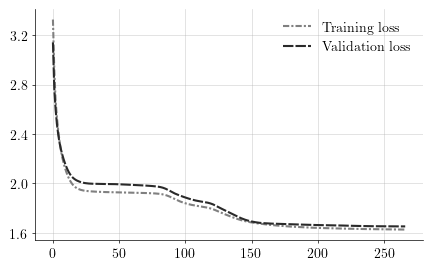

In [18]:
with plt.style.context("sbijax-grayish"):
    sbijax.plot_loss_profile(losses[1:])
    plt.show()

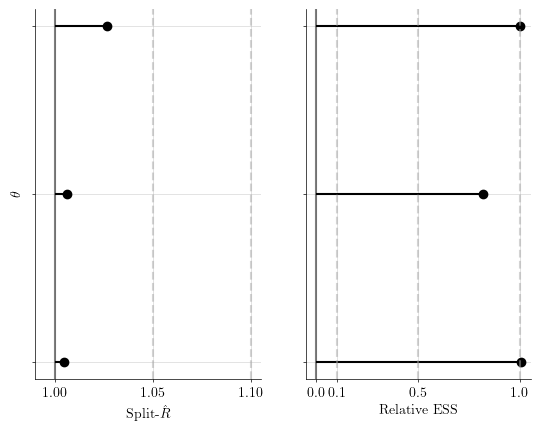

In [19]:
sbijax.plot_rhat_and_ress(inference_results)
plt.show()

/Users/simon/PROJECTS/sbijax/.venv/lib/python3.12/site-packages/arviz_plots/backend/matplotlib/core.py:428: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  return target.scatter(x, y, **_filter_kwargs(kwargs, None, artist_kws))
/Users/simon/PROJECTS/sbijax/.venv/lib/python3.12/site-packages/arviz_plots/backend/matplotlib/core.py:428: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  return target.scatter(x, y, **_filter_kwargs(kwa

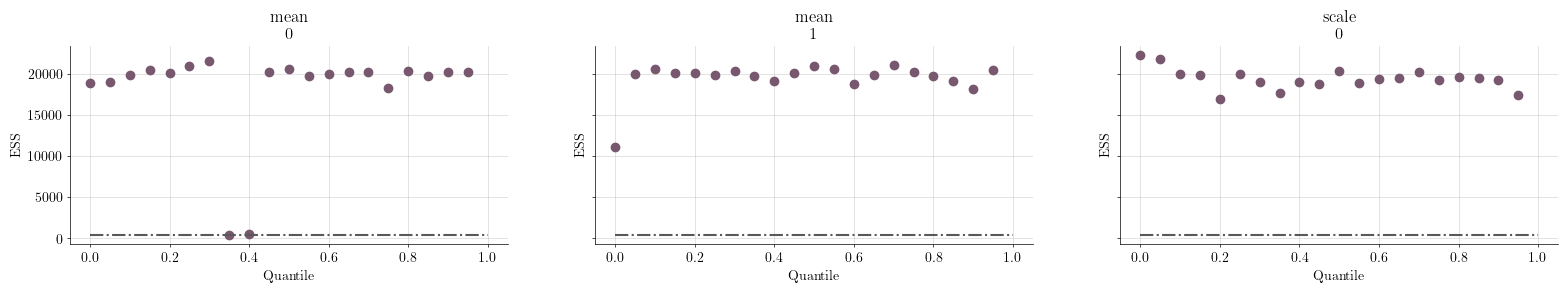

In [20]:
with sns.color_palette(sns.blend_palette(["#78586f", "#c79999"])):    
    sbijax.plot_ess(inference_results)
    plt.show()

## Sequential inference

`sbijax` supports sequential training.

In [21]:
from sbijax.util import stack_data

n_rounds = 1
data, params = None, {}
for i in range(n_rounds):
    new_data, _ = model.simulate_data(
        jr.fold_in(jr.PRNGKey(1), i),
        params=params,
        observable=y_obs,
        data=data,
    )
    data = stack_data(data, new_data)
    params, info = model.fit(jr.fold_in(jr.PRNGKey(2), i), data=data)

_ = model.sample_posterior(
    jr.PRNGKey(3), params, y_obs
)

 28%|█████████████████████████████████████████████████████████████████████████████████████▍                                                                                                                                                                                                                         | 282/1000 [01:50<04:42,  2.54it/s]


## Session info

In [22]:
import session_info

session_info.show(html=False)

-----
haiku                       0.0.16
jax                         0.8.1
jaxlib                      0.8.1
matplotlib                  3.10.8
sbijax                      0.3.6
seaborn                     0.13.2
session_info                v1.0.1
surjectors                  0.3.3
tensorflow_probability      0.26.0-dev20260318
xarray                      2026.2.0
-----
IPython             9.11.0
jupyter_client      8.8.0
jupyter_core        5.9.1
jupyterlab          4.5.6
notebook            7.5.5
-----
Python 3.12.10 (main, May 30 2025, 05:53:56) [Clang 20.1.4 ]
macOS-26.2-arm64-arm-64bit
-----
Session information updated at 2026-03-19 14:14
